# Age-Dependent Gene De-repression in BICAN D1 Matrix SPNs

Tests whether de-repression scores increase with **age alone**, using BICAN
(healthy donors only). No disease comparison — pure age trajectory.

**Pipeline per zone:**
1. Subset BICAN to the zone of interest (zones 1–6)
2. Identify candidate de-repressed genes (silent in young donors, re-expressed in old)
3. Score every cell with an AUCell gene-set score
4. Aggregate to donor level and test `score ~ age` with OLS
5. Visualise the age trajectory

## Setup

In [5]:
%load_ext autoreload
%autoreload 2

import re
import os

import numpy as np
import pandas as pd
import scipy.sparse
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import decoupler as dc
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from dotenv import load_dotenv

load_dotenv()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


True

In [6]:
# ── Column names (as they appear after renaming below) ────────────────────────
SAMPLE_VARIABLE  = "donor_id"
AGE              = "age_of_death"
ZONE_COL         = "zone"
LIBRARY_SIZE_COL = "total_counts"

# ── Covariates available in BICAN ─────────────────────────────────────────────
# sex + first 5 ancestry principal components
BICAN_COV = ["sex", "PC1", "PC2", "PC3", "PC4", "PC5"]

# ── Zones to run ──────────────────────────────────────────────────────────────
ZONES = [1, 2, 3, 4, 5, 6]

# ── Quality filters ───────────────────────────────────────────────────────────
MIN_CELLS_PER_DONOR = 10   # donors with fewer cells are dropped before analysis

# ── De-repression detection parameters ───────────────────────────────────────
THRESHOLD = 0.02   # max detection rate in young donors to call a gene "silent"

## Helper Functions

In [7]:
def find_derepressed_genes(
    adata,

    # --- Required column names in adata.obs ---
    age_col          = "age",
    donor_col        = "donor_id",

    # --- Per-cell total UMI counts column in adata.obs ---
    # Used to compute mean log(UMI) per donor as a sequencing depth covariate.
    # Set to None to auto-detect from common names.
    counts_col       = None,

    # --- Other covariates (sex, ancestry PCs, etc.) ---
    other_covariate_cols = ["sex", "PC1", "PC2", "PC3", "PC4", "PC5"],

    # --- Detection threshold: max detection rate allowed in young donors ---
    threshold        = 0.05,

    # --- Age group definitions ---
    young_quantile   = 0.25,
    old_quantile     = 0.75,

    # --- Quality filters ---
    min_cells        = 30,
    fdr_threshold    = 0.05,
    exclude_pattern  = r"^MT-|^RPS\d|^RPL\d|^HB[^P]",

    # --- Permutation settings ---
    n_perm           = 10000,
    seed             = 42,
):
    """
    Identify genes that are silenced in young donors and significantly
    re-expressed (de-repressed) with age.

    Mirrors the logic of derepression_threshold_forward.py.

    Parameters
    ----------
    adata                : AnnData — cells × genes, raw counts in adata.X.
                           Filter to your cell type and zone BEFORE calling.
    age_col              : str  — per-cell donor age column
    donor_col            : str  — per-cell donor ID column
    counts_col           : str or None — per-cell total UMI column (auto-detected if None)
    other_covariate_cols : list — additional covariates (sex, PCs)
    threshold            : float — max detection rate defining "silent in young"
    young_quantile       : float — age quantile cutoff for "young" group
    old_quantile         : float — age quantile cutoff for "old" group
    min_cells            : int   — drop donors with fewer cells than this
    fdr_threshold        : float — BH-adjusted p-value cutoff
    exclude_pattern      : str   — regex of gene prefixes to always exclude
    n_perm               : int   — number of permutations
    seed                 : int   — random seed for reproducibility

    Returns
    -------
    pd.DataFrame with columns:
        gene, young_detect, old_detect, delta_detect, exceeds_in_old,
        obs_beta, perm_pval, perm_padj, significant
    """

    rng = np.random.RandomState(seed)

    # ── 0. Validate inputs and auto-detect counts column ──────────────────────
    check_cols = [age_col, donor_col] + other_covariate_cols
    missing = [c for c in check_cols if c not in adata.obs.columns]
    if missing:
        raise ValueError(f"Columns not found in adata.obs: {missing}")

    if counts_col is None:
        _candidates = ["n_counts", "total_counts", "nCounts", "nUMI", "n_umi", "total_UMI"]
        _found = [c for c in _candidates if c in adata.obs.columns]
        if not _found:
            raise ValueError(
                f"Could not auto-detect counts column. Tried: {_candidates}\n"
                f"Pass counts_col='your_column' explicitly."
            )
        counts_col = _found[0]
        print(f"Auto-detected counts column: '{counts_col}'")
    elif counts_col not in adata.obs.columns:
        raise ValueError(f"counts_col='{counts_col}' not found in adata.obs.")

    # ── 1. Prepare sparse count matrix ────────────────────────────────────────
    X = adata.X
    if not scipy.sparse.issparse(X):
        X = scipy.sparse.csr_matrix(X)
    elif not scipy.sparse.isspmatrix_csr(X):
        X = X.tocsr()

    donors_array = adata.obs[donor_col].values
    counts_array = adata.obs[counts_col].values.astype(float)
    gene_names   = adata.var_names.tolist()
    n_genes      = len(gene_names)

    # ── 2. Filter donors by minimum cell count ────────────────────────────────
    unique_donors, cell_counts = np.unique(donors_array, return_counts=True)
    donor_ncells = dict(zip(unique_donors, cell_counts))
    valid_donors = [d for d, n in donor_ncells.items() if n >= min_cells]
    n_dropped    = len(donor_ncells) - len(valid_donors)

    if n_dropped:
        print(f"Dropped {n_dropped} donors with < {min_cells} cells")
    if not valid_donors:
        raise ValueError("No donors passed the minimum cell count filter")

    # ── 3. Downsample all donors to the same number of cells ──────────────────
    # A donor with more cells detects more genes purely due to sampling.
    # Equalising cell counts removes this confound before computing detection rates.
    min_n = min(donor_ncells[d] for d in valid_donors)
    print(f"{len(valid_donors)} valid donors — downsampling each to {min_n} cells")

    # ── 4. Compute per-donor detection rates and mean log UMI ─────────────────
    detect_matrix = np.zeros((n_genes, len(valid_donors)), dtype=np.float32)
    mean_log_umi  = np.zeros(len(valid_donors),            dtype=np.float64)
    meta_rows     = []

    for j, donor in enumerate(valid_donors):
        cell_idx = np.where(donors_array == donor)[0]

        # Subsample to min_n
        if len(cell_idx) > min_n:
            cell_idx = rng.choice(cell_idx, size=min_n, replace=False)

        # Detection rate: fraction of subsampled cells with >= 1 count
        detected            = np.asarray((X[cell_idx, :] > 0).sum(axis=0)).ravel()
        detect_matrix[:, j] = detected / min_n

        # Sequencing depth covariate: mean log(UMI) across subsampled cells
        mean_log_umi[j] = np.log1p(counts_array[cell_idx]).mean()

        meta_rows.append(adata.obs[donors_array == donor].iloc[0])

    meta     = pd.DataFrame(meta_rows).reset_index(drop=True)
    n_donors = len(valid_donors)

    # ── 5. Define young and old donor groups ──────────────────────────────────
    ages       = meta[age_col].values.astype(float)
    q_young    = np.quantile(ages, young_quantile)
    q_old      = np.quantile(ages, old_quantile)
    young_mask = ages <= q_young
    old_mask   = ages >= q_old

    print(f"Young (age <= {q_young:.0f}): {young_mask.sum()} donors | "
          f"Old   (age >= {q_old:.0f}):   {old_mask.sum()} donors")

    young_detect = detect_matrix[:, young_mask].mean(axis=1)
    old_detect   = detect_matrix[:, old_mask].mean(axis=1)

    # ── 6. Select candidate genes ─────────────────────────────────────────────
    # Candidates: silent in young (mean detection <= threshold) + not housekeeping
    exclude_re   = re.compile(exclude_pattern)
    exclude_mask = np.array([bool(exclude_re.match(g)) for g in gene_names])

    candidate_mask = (young_detect <= threshold) & (~exclude_mask)
    n_candidates   = candidate_mask.sum()
    print(f"Candidate genes silent in young (threshold={threshold*100:.1f}%): {n_candidates}")

    if n_candidates == 0:
        raise ValueError(
            "No candidate genes found. Try:\n"
            "  - Increasing threshold (e.g. 0.05)\n"
            "  - Reducing min_cells to keep more donors\n"
            "  - Checking adata.X contains raw counts (not normalised)"
        )

    detect_cand = detect_matrix[candidate_mask, :]
    cand_genes  = [g for g, m in zip(gene_names, candidate_mask) if m]

    # ── 7. Build covariate matrix (intercept + depth + depth² + other covariates)
    # depth²  always included to capture non-linear sequencing depth effects
    cov_arrays = [
        np.ones(n_donors),
        mean_log_umi,
        mean_log_umi ** 2,
    ]
    for col in other_covariate_cols:
        raw = meta[col].values
        try:
            vals = raw.astype(float)
        except (ValueError, TypeError):
            # Encode categorical strings (e.g. 'F'/'M') as integers
            unique_vals = sorted(set(raw))
            mapping     = {v: i for i, v in enumerate(unique_vals)}
            vals        = np.array([mapping[v] for v in raw], dtype=float)
            print(f"Encoded '{col}': {mapping}")
        cov_arrays.append(vals)

    X_cov = np.column_stack(cov_arrays)
    Q, _  = np.linalg.qr(X_cov, mode="reduced")

    # ── 8. FWL residualisation ────────────────────────────────────────────────
    # Remove covariate effects from both age and detection rates before
    # computing the age slope (Frisch–Waugh–Lovell theorem).
    age_resid    = ages - Q @ (Q.T @ ages)
    ss_age       = np.sum(age_resid ** 2)

    if ss_age < 1e-12:
        # Diagnose which covariate is eating age variance
        print("\n--- COLLINEARITY DIAGNOSTIC ---")
        print(f"Age variance before residualisation: {np.var(ages):.4f}")
        for col_name, col_vec in zip(
            ["intercept", "mean_log_umi", "mean_log_umi²"] + other_covariate_cols,
            cov_arrays
        ):
            r = np.corrcoef(ages, col_vec)[0, 1]
            print(f"  corr(age, {col_name}) = {r:.4f}")
        raise ValueError(
            "No age variance after residualisation.\n"
            "Most likely cause: a covariate is perfectly predicted by age.\n"
            "Check the correlations above and remove the offending covariate."
        )

    detect_resid = detect_cand - (Q @ (Q.T @ detect_cand.T)).T
    obs_betas    = (detect_resid @ age_resid) / ss_age

    # ── 9. Permutation test (one-sided: detection increases with age) ─────────
    print(f"Running {n_perm} permutations ...", flush=True)

    perm_indices   = np.column_stack([rng.permutation(n_donors) for _ in range(n_perm)])
    age_perm_mat   = ages[perm_indices]
    age_resid_perm = age_perm_mat - Q @ (Q.T @ age_perm_mat)
    ss_perm        = np.sum(age_resid_perm ** 2, axis=0)

    beta_perm_mat  = (detect_resid @ age_resid_perm) / ss_perm
    perm_counts    = np.sum(beta_perm_mat >= obs_betas[:, np.newaxis], axis=1)
    perm_pvals     = (1 + perm_counts) / (1 + n_perm)

    # ── 10. BH FDR correction ─────────────────────────────────────────────────
    _, perm_padjs, _, _ = multipletests(perm_pvals, method="fdr_bh")

    # ── 11. Assemble results table ────────────────────────────────────────────
    results = pd.DataFrame({
        "gene"         : cand_genes,
        "young_detect" : young_detect[candidate_mask],
        "old_detect"   : old_detect[candidate_mask],
        "delta_detect" : old_detect[candidate_mask] - young_detect[candidate_mask],
        "exceeds_in_old": old_detect[candidate_mask] > threshold,
        "obs_beta"     : obs_betas,
        "perm_pval"    : perm_pvals,
        "perm_padj"    : perm_padjs,
        "significant"  : (perm_padjs < fdr_threshold) & (obs_betas > 0),
    }).sort_values("obs_beta", ascending=False).reset_index(drop=True)

    n_sig        = results["significant"].sum()
    n_sig_exceed = (results["significant"] & results["exceeds_in_old"]).sum()
    print(f"\nSignificant (padj < {fdr_threshold}): {n_sig}")
    print(f"  of which exceed threshold in old:   {n_sig_exceed}")
    print(f"\nTo relax significance:")
    print(f"  results[results['perm_pval'] < 0.05]   # skip FDR correction")
    print(f"  results[results['perm_padj'] < 0.10]   # 10% FDR")
    print(f"  re-run with threshold=0.05, min_cells=10")

    return results

---
## 1. Load BICAN Data

The BICAN object already contains only **D1 Matrix SPNs** (pre-filtered).
All donors are healthy controls — no disease comparison.

In [8]:
BICAN_PATH = "/home/gdallagl/myworkdir/XDP/data/BICAN/STR_D1_Matrix/d1_cleaner_v3_raw_dv_wm_labeled.h5ad"

bican = sc.read_h5ad(BICAN_PATH, backed="r")

# Rename columns to a consistent naming convention
bican.obs = bican.obs.rename(columns={
    "merge_step_6" : ZONE_COL,
    "donor_id"     : SAMPLE_VARIABLE,
    "age"          : AGE,
    "n_counts"     : LIBRARY_SIZE_COL,
    "imputed_sex"  : "sex",
})

print(bican)
print(f"\nDonors : {bican.obs[SAMPLE_VARIABLE].nunique()}")
print(f"Zones  : {sorted(bican.obs[ZONE_COL].unique())}")
print(f"Age range: {bican.obs[AGE].min():.0f}–{bican.obs[AGE].max():.0f}")

AnnData object with n_obs × n_vars = 206571 × 38100 backed at '/home/gdallagl/myworkdir/XDP/data/BICAN/STR_D1_Matrix/d1_cleaner_v3_raw_dv_wm_labeled.h5ad'
    obs: 'prefix', 'cell_barcode', 'expression_doublet', 'num_genic_reads', 'num_transcripts', 'num_genes', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_intronic', 'pct_mt', 'frac_contamination', 'donor_external_id', 'biobank', 'cohort', 'age_of_death', 'race', 'pmi_hr', 'sex', 'eur_adj', 'afr_adj', 'nat_adj', 'eas_adj', 'sas_adj', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'toxicology_group', 'toxicology_report_complete', 'toxicology_compounds_detected', 'hbcac_status', 'experiment', 'scpred_cortex_class', 'scpred_cortex_class_max_prob', 'scpred_cortex_gaba_sub_class', 'scpred_cortex_gaba_sub_class_max_prob', 'scpred_cortex_glut_sub_class', 'scpred_cortex_glut_sub_class_max_prob', 'scpred_caudate_class', 'scpred_caudate_class_max_prob', 'scpred_caudate_spn_di', 'scpred_caudate_spn_di_max_prob', 'scpred_caudate

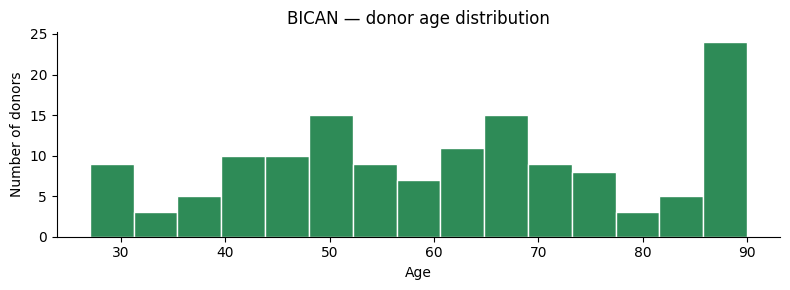

In [9]:
# Quick overview of donor ages across the full dataset
donor_meta = bican.obs.drop_duplicates(SAMPLE_VARIABLE)[[SAMPLE_VARIABLE, AGE]].copy()
donor_meta[AGE] = donor_meta[AGE].astype(float)

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(donor_meta[AGE], bins=15, color="seagreen", edgecolor="white")
ax.set_xlabel("Age")
ax.set_ylabel("Number of donors")
ax.set_title("BICAN — donor age distribution")
sns.despine()
plt.tight_layout()
plt.show()

---
## 2. Per-Zone Analysis (Zones 1–6)

For each zone we:
1. Subset cells and filter low-cell donors
2. Identify de-repressed genes with `find_derepressed_genes`
3. Score cells with AUCell
4. Aggregate to donor level and fit `score ~ age`

Results for all zones are collected in `zone_results`.

In [10]:
# Storage for per-zone outputs
zone_results = {}  # zone → dict with derep genes, summary df, OLS model

for zone in ZONES:
    print("\n" + "=" * 60)
    print(f"  ZONE {zone}")
    print("=" * 60)

    # ── 2.1 Subset to zone and load into memory ────────────────────────────
    bican_zone = bican[bican.obs[ZONE_COL] == zone].to_memory().copy()
    print(f"Zone {zone}: {bican_zone.n_obs} cells, "
          f"{bican_zone.obs[SAMPLE_VARIABLE].nunique()} donors")

    # ── 2.2 Drop donors with too few cells ────────────────────────────────
    # Donors with very few cells give unreliable detection-rate estimates.
    counts_per_donor = bican_zone.obs[SAMPLE_VARIABLE].value_counts()
    keep_donors = counts_per_donor[counts_per_donor >= MIN_CELLS_PER_DONOR].index
    bican_zone  = bican_zone[bican_zone.obs[SAMPLE_VARIABLE].isin(keep_donors)].copy()
    print(f"After cell filter: {bican_zone.obs[SAMPLE_VARIABLE].nunique()} donors")

    if bican_zone.obs[SAMPLE_VARIABLE].nunique() < 6:
        print(f"  !! Fewer than 6 donors — skipping zone {zone}")
        continue

    # ── 2.3 Find de-repressed genes ───────────────────────────────────────
    # Uses BICAN (healthy only), so the candidate list is not contaminated by disease.
    results = find_derepressed_genes(
        bican_zone,
        age_col              = AGE,
        donor_col            = SAMPLE_VARIABLE,
        counts_col           = LIBRARY_SIZE_COL,
        other_covariate_cols = BICAN_COV,
        threshold            = THRESHOLD,
    )

    sig_genes = results[results["significant"]]["gene"].tolist()
    print(f"Significant de-repressed genes: {len(sig_genes)}")

    if len(sig_genes) == 0:
        print(f"  !! No significant genes — skipping AUCell for zone {zone}")
        zone_results[zone] = {"derep_results": results, "sig_genes": [], "summary": None, "model": None}
        continue

    # ── 2.4 Normalise (log1p CPM) for AUCell ──────────────────────────────
    # Raw counts go into a layer; normalised values used only for scoring.
    bican_zone.layers["counts"] = bican_zone.X.copy()
    sc.pp.normalize_total(bican_zone, target_sum=1e4)
    sc.pp.log1p(bican_zone)
    bican_zone.layers["log1p_norm"] = bican_zone.X.copy()
    bican_zone.X = bican_zone.layers["counts"]  # restore raw counts

    # ── 2.5 AUCell scoring ─────────────────────────────────────────────────
    # Build a simple gene-set network (all genes with equal weight)
    net = pd.DataFrame({
        "source" : "derepressed",
        "target" : sig_genes,
        "weight" : 1.0,
    })

    dc.mt.aucell(
        data    = bican_zone,
        net     = net,
        tmin    = 3,
        n_up    = bican_zone.n_vars // 2,
        layer   = "log1p_norm",
        raw     = False,
        bsize   = 250_000,
        verbose = False,
    )
    bican_zone.obs["derepressed_score"] = (
        bican_zone.obsm["score_aucell"]["derepressed"].values
    )

    # ── 2.6 Aggregate to donor level ───────────────────────────────────────
    # Use the 90th percentile of per-cell scores as the donor-level summary.
    # This is robust to cells with zero score and captures the "highest expressing" tail.
    summary = (
        bican_zone.obs
        .groupby(SAMPLE_VARIABLE, observed=True)
        .agg(
            pct90_derepressed = ("derepressed_score", lambda x: np.percentile(x, 90)),
            age               = (AGE,              "first"),
            median_umi        = (LIBRARY_SIZE_COL, "median"),
        )
        .reset_index()
    )
    summary["age"]       = summary["age"].astype(float)
    summary["age_scaled"] = (
        (summary["age"] - summary["age"].mean()) / summary["age"].std()
    )
    summary["median_umi_scaled"] = (
        (summary["median_umi"] - summary["median_umi"].mean()) / summary["median_umi"].std()
    )

    # ── 2.7 OLS: score ~ age + sequencing depth ────────────────────────────
    # We control for median UMI to remove any confound between age and depth.
    model = smf.ols(
        "pct90_derepressed ~ age_scaled + median_umi_scaled",
        data=summary,
    ).fit()

    age_coef  = model.params["age_scaled"]
    age_pval  = model.pvalues["age_scaled"]
    print(f"OLS age coef = {age_coef:+.4f}, p = {age_pval:.4f}")

    # Store everything for later inspection / plotting
    zone_results[zone] = {
        "derep_results" : results,
        "sig_genes"     : sig_genes,
        "summary"       : summary,
        "model"         : model,
    }


  ZONE 1
Zone 1: 26409 cells, 141 donors
After cell filter: 124 donors
Dropped 10 donors with < 30 cells
114 valid donors — downsampling each to 32 cells
Young (age <= 47): 29 donors | Old   (age >= 75):   30 donors
Candidate genes silent in young (threshold=2.0%): 14785
Running 10000 permutations ...

Significant (padj < 0.05): 0
  of which exceed threshold in old:   0

To relax significance:
  results[results['perm_pval'] < 0.05]   # skip FDR correction
  results[results['perm_padj'] < 0.10]   # 10% FDR
  re-run with threshold=0.05, min_cells=10
Significant de-repressed genes: 0
  !! No significant genes — skipping AUCell for zone 1

  ZONE 2
Zone 2: 31195 cells, 141 donors
After cell filter: 133 donors
Dropped 10 donors with < 30 cells
123 valid donors — downsampling each to 31 cells
Young (age <= 47): 32 donors | Old   (age >= 76):   32 donors
Candidate genes silent in young (threshold=2.0%): 14424
Running 10000 permutations ...

Significant (padj < 0.05): 30
  of which exceed thr

---
## 3. Summary Table — Age Effect Across Zones

In [11]:
rows = []
for zone, res in zone_results.items():
    if res["model"] is None:
        rows.append({"zone": zone, "n_sig_genes": len(res["sig_genes"]),
                     "n_donors": None, "age_coef": None, "age_pval": None})
        continue
    model   = res["model"]
    summary = res["summary"]
    rows.append({
        "zone"        : zone,
        "n_sig_genes" : len(res["sig_genes"]),
        "n_donors"    : len(summary),
        "age_coef"    : model.params["age_scaled"],
        "age_pval"    : model.pvalues["age_scaled"],
    })

summary_table = pd.DataFrame(rows)
summary_table["age_pval_rounded"] = summary_table["age_pval"].map(
    lambda p: f"{p:.4f}" if p is not None else "—"
)
display(summary_table)

,zone,n_sig_genes,n_donors,age_coef,age_pval,age_pval_rounded
0,1,0,NaN,NaN,NaN,nan
1,2,30,133.0,0.004482,1.576110e-11,0.0000
2,3,86,138.0,0.003642,5.007687e-05,0.0001
3,4,86,139.0,-0.000425,6.177286e-01,0.6177
4,5,40,127.0,0.003692,4.527055e-03,0.0045
5,6,0,NaN,NaN,NaN,nan


---
## 4. Visualisation — De-repression Score vs Age (per zone)

Each point is one donor. The fitted OLS line (controlling for UMI) is overlaid.

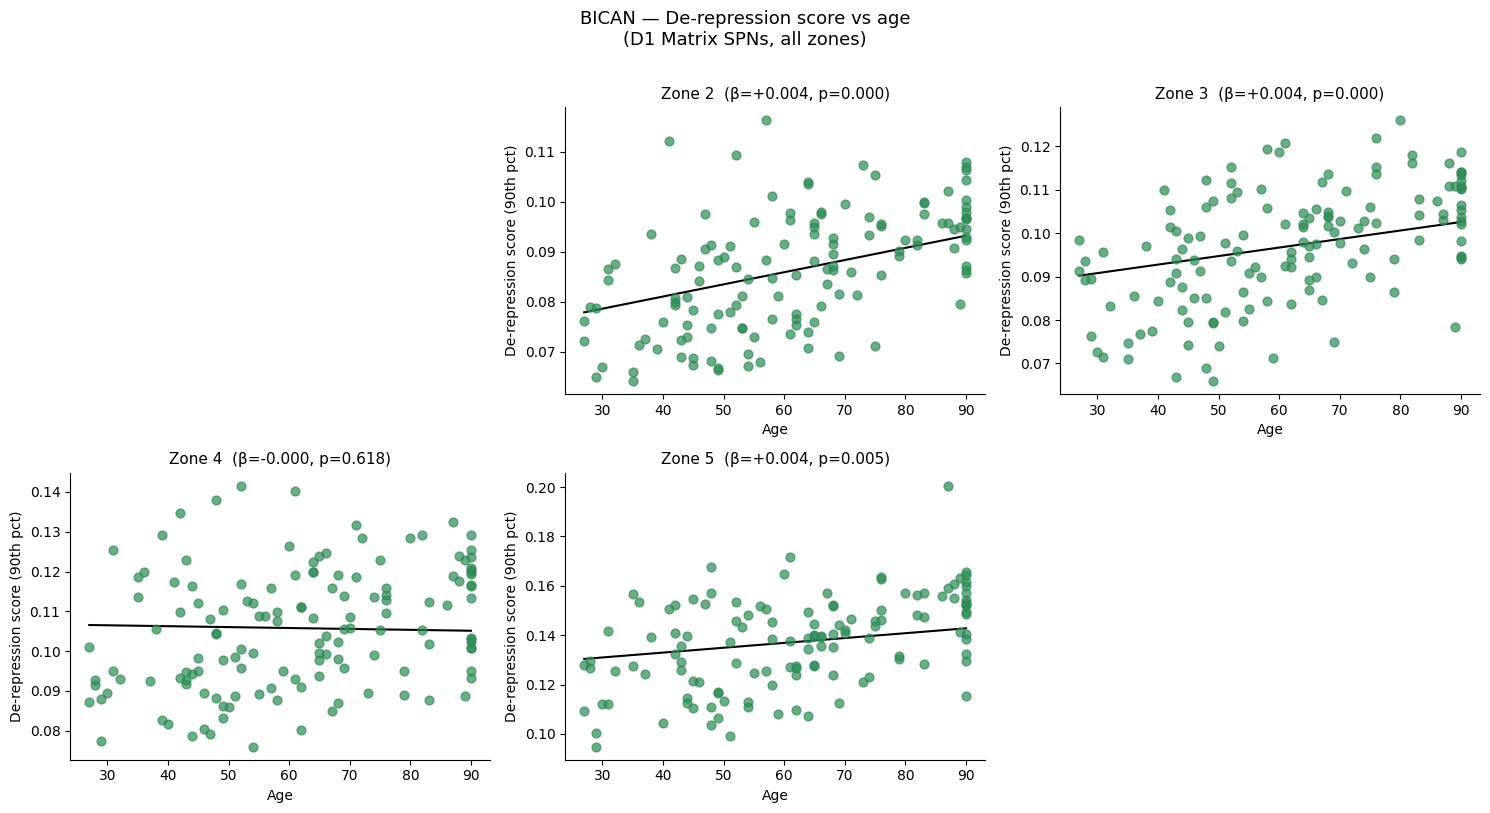

In [12]:
n_zones  = len(zone_results)
n_cols   = 3
n_rows   = (n_zones + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes      = axes.flatten()

for ax, (zone, res) in zip(axes, zone_results.items()):
    if res["summary"] is None:
        ax.set_title(f"Zone {zone} — skipped")
        ax.set_visible(False)
        continue

    summary = res["summary"]
    model   = res["model"]

    # Scatter: raw age vs score
    ax.scatter(summary["age"], summary["pct90_derepressed"],
               color="seagreen", alpha=0.7, s=40, zorder=3)

    # OLS trend line (marginalised over UMI at its mean)
    age_range = np.linspace(summary["age"].min(), summary["age"].max(), 100)
    age_range_scaled = (age_range - summary["age"].mean()) / summary["age"].std()
    pred = model.predict(pd.DataFrame({
        "age_scaled"        : age_range_scaled,
        "median_umi_scaled" : np.zeros(100),  # UMI at its mean
    }))
    ax.plot(age_range, pred, color="black", linewidth=1.5, label="OLS fit")

    # Annotation
    coef = model.params["age_scaled"]
    pval = model.pvalues["age_scaled"]
    ax.set_title(f"Zone {zone}  (β={coef:+.3f}, p={pval:.3f})", fontsize=11)
    ax.set_xlabel("Age")
    ax.set_ylabel("De-repression score (90th pct)")
    sns.despine(ax=ax)

# Hide any unused subplot panels
for ax in axes[len(zone_results):]:
    ax.set_visible(False)

fig.suptitle("BICAN — De-repression score vs age\n(D1 Matrix SPNs, all zones)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

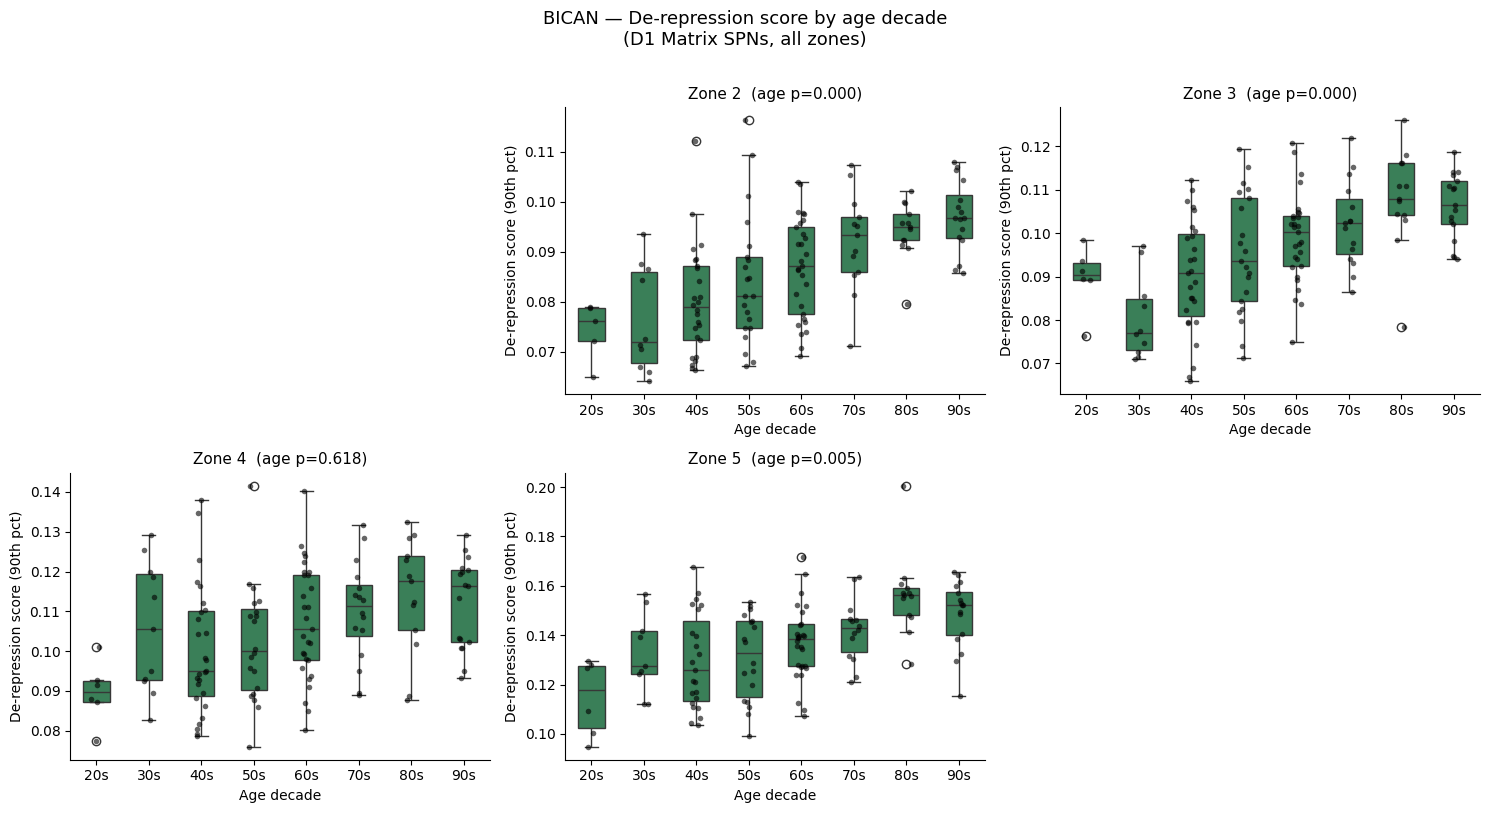

In [13]:
# Alternative view: boxplot per age decade, one panel per zone
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes      = axes.flatten()

for ax, (zone, res) in zip(axes, zone_results.items()):
    if res["summary"] is None:
        ax.set_visible(False)
        continue

    summary = res["summary"].copy()
    summary["age_decade"] = (summary["age"] // 10 * 10).astype(int).astype(str) + "s"
    decade_order = sorted(summary["age_decade"].unique())

    sns.boxplot(
        data=summary, x="age_decade", y="pct90_derepressed",
        order=decade_order, color="seagreen", width=0.5, ax=ax,
    )
    sns.stripplot(
        data=summary, x="age_decade", y="pct90_derepressed",
        order=decade_order, color="black", size=4, alpha=0.6, ax=ax,
    )

    pval = res["model"].pvalues["age_scaled"]
    ax.set_title(f"Zone {zone}  (age p={pval:.3f})", fontsize=11)
    ax.set_xlabel("Age decade")
    ax.set_ylabel("De-repression score (90th pct)")
    sns.despine(ax=ax)

for ax in axes[len(zone_results):]:
    ax.set_visible(False)

fig.suptitle("BICAN — De-repression score by age decade\n(D1 Matrix SPNs, all zones)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Per-Zone Detail

Inspect the full OLS summary and de-repressed gene list for any zone of interest.

In [16]:
INSPECT_ZONE = 2  # change this to inspect a different zone

res = zone_results[INSPECT_ZONE]

print(f"=== Zone {INSPECT_ZONE} — OLS summary ===")
print(res["model"].summary())

=== Zone 2 — OLS summary ===
                            OLS Regression Results                            
Dep. Variable:      pct90_derepressed   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.680
Method:                 Least Squares   F-statistic:                     141.2
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           2.61e-33
Time:                        14:33:46   Log-Likelihood:                 478.45
No. Observations:                 133   AIC:                            -950.9
Df Residuals:                     130   BIC:                            -942.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept

In [15]:
print(f"=== Zone {INSPECT_ZONE} — significant de-repressed genes ===")
display(
    res["derep_results"][res["derep_results"]["significant"]]
    .sort_values("obs_beta", ascending=False)
    .head(30)
)

=== Zone 4 — significant de-repressed genes ===


,gene,young_detect,old_detect,delta_detect,exceeds_in_old,obs_beta,perm_pval,perm_padj,significant
0,TMEM26-AS1,0.013949,0.066359,0.052410,True,0.001393,0.0001,0.024647,True
2,ENSG00000270114,0.019180,0.053456,0.034276,True,0.001020,0.0001,0.024647,True
3,HSD17B11,0.016565,0.063594,0.047030,True,0.001011,0.0001,0.024647,True
7,GFAP,0.013078,0.049770,0.036692,True,0.000786,0.0001,0.024647,True
13,ENSG00000287684,0.010462,0.029493,0.019031,True,0.000605,0.0001,0.024647,True
14,ENSG00000250230,0.013078,0.033180,0.020102,True,0.000597,0.0002,0.039024,True
17,CR2,0.015693,0.034101,0.018408,True,0.000563,0.0003,0.049007,True
19,HEBP2,0.006103,0.032258,0.026155,True,0.000533,0.0001,0.024647,True
20,DUOX2,0.015693,0.025806,0.010113,True,0.000527,0.0001,0.024647,True
24,ENSG00000275632,0.019180,0.035023,0.015843,True,0.000521,0.0002,0.039024,True
